## Steps 1+2 Model

- Joint Inference
- PPCA
- BGP

### Imports

In [1]:
# Adjust import path
import sys
sys.path.append("../things")
sys.path.append("helpers")
sys.path.append("../")

import os
import h5py
import numpy as np

import opinf

import config
import utils
import step1_generate_data as step1

import matplotlib.pyplot as plt
from ppca_jax import BayesianPPCA
import jax.numpy as jnp
import jax

Logging to log.log
Logging to log.log


#### Generate Noisy Data

In [2]:
training_span = (0, 6) # (0, 6)
num_samples= 400 # 400
noiselevel= .1 # 0
num_regression_points= 400 # 400
numPODmodes= 3 # 3
gp_regularizer= 1e-4 # 1e-4
ndraws=100 # 100
exportto=None
openonsave=False
ddtdata=False

config.time_domain = np.linspace(0, 8, 801)  # Temporal domain t.

In [3]:
if isinstance(numPODmodes, (list, tuple)) and len(numPODmodes) == 1:
    numPODmodes = numPODmodes[0]

# Report on experimental scenario.
utils.summarize_experiment(
    training_span=training_span,
    num_samples=num_samples,
    noiselevel=noiselevel,
    num_regression_points=num_regression_points,
    numPODmodes=numPODmodes,
    gp_regularizer=gp_regularizer,
    ndraws=ndraws,
)

# Step 1: Generate data ---------------------------------------------------
(
    model,
    time_domain,
    true_states,
    time_domain_sampled,
    snapshots_sampled,
) = step1.trajectory(training_span, num_samples, config, noiselevel)

time_domain_training = np.linspace(
    training_span[0],
    training_span[-1],
    num_regression_points,
)


EXPERIMENTAL SCENARIO
Data: 400 uniformly sampled snapshots over 0.00 ≤ t < 6.00 with 10.00% noise
Dimension: retaining 3 POD modes
Training: using 400 regression points
GP regularization: eta = 1.00e-04
Posterior: 100 draws

generating training data...done in 0.53 s.


#### Do a deterministic fit

reducing noisy training states to 3 dimensions...Basis
  full_state_dimension:    None
  reduced_state_dimension: None
  SVD solver: scipy.linalg.svd()
Snapshot sampled shape: (1024, 400)
(512, 400) (512, 400)
(3, 801)
done in 0.09 s.


INFO:2025-06-25 16:34:40,845:jax._src.xla_bridge:752: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/Users/anthonypoole/miniconda3/envs/prob_rom/bin/../lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)


Weight matrix None
Off diagonal loss -1.3287982e-15


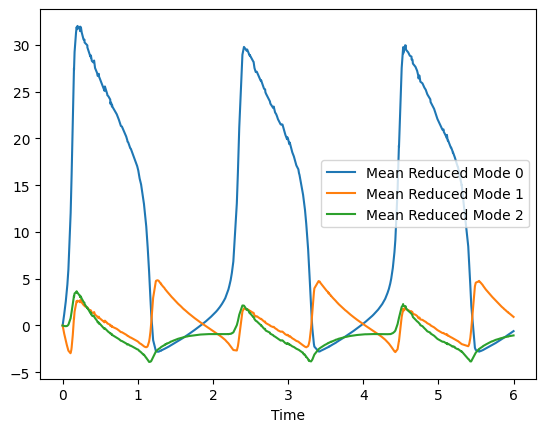

In [4]:
# Dimensionality reduction (POD).
with opinf.utils.TimedBlock(
    f"reducing noisy training states to {numPODmodes} dimensions"
):
    basis = config.Basis(num_vectors=numPODmodes)
    print(basis)
    print(f"Snapshot sampled shape: {snapshots_sampled.shape}")
    basis.fit(snapshots_sampled)
    # print(f"{}")
    snapshots_compressed = basis.compress(snapshots_sampled)
    full_states_compressed = basis.compress(true_states)
    print(full_states_compressed.shape)

V = basis.entries
W = basis.weights
print(f'Weight matrix', W)

off_diagonal_loss = jnp.sum((V.T @ V) - jnp.eye(V.shape[1])**2)
print("Off diagonal loss", off_diagonal_loss)

for i in range(numPODmodes):
    plt.plot(time_domain_sampled, snapshots_compressed[i], label = f"Mean Reduced Mode {i}")
plt.xlabel('Time')
plt.legend()

### Create helper class to extend BayesianPPCA

In [5]:
# Fixed implementation of LiftedPPCA with cleaner dimension handling
class LiftedPPCA(BayesianPPCA):
    def __init__(self, *args, **kwargs):
        # Store the original observation dimension before lifting
        super().__init__(*args, **kwargs)
        self.original_obs_dim = None
        
    def lift_data(self, states):
        """
        Lift the data by adding nonlinear features.
        
        Args:
            states: Array of shape (time_dim, param_dim)
        
        Returns:
            Lifted states of shape (time_dim, lifted_param_dim)
        """
        # Split parameters in half (assuming param_dim is even)
        q1, q2 = jnp.split(states, 2, axis=1)  # Split along param dimension
        # Add quadratic features
        return jnp.concatenate([q1, q2, q1**2], axis=1)
    
    def unlift_data(self, lifted_states):
        """
        Extract original states from lifted representation.
        
        Args:
            lifted_states: Array of shape (time_dim, lifted_param_dim)
            
        Returns:
            Original states of shape (time_dim, param_dim)
        """
        # Split into three parts: q1, q2, and q1^2
        q1, q2, _ = jnp.split(lifted_states, 3, axis=1)
        return jnp.concatenate([q1, q2], axis=1)
    
    def fit(self, states, num_samples, warmup_steps, rng_key, penalty=False):
        """
        Fit the model on lifted data.
        
        Args:
            states: Array of shape (param_dim, time_dim) - original format
        """
        # Convert to standard format: (time_dim, param_dim)
        states_standard = states.T
        
        # Store original dimension
        self.original_obs_dim = states_standard.shape[1]
        
        # Lift the data
        lifted_states = self.lift_data(states_standard)
        
        # Update obs_dim for the lifted space
        self.obs_dim = lifted_states.shape[1]
        
        # Fit on lifted data
        super().fit(lifted_states, 
                   num_samples=num_samples, 
                   warmup_steps=warmup_steps, 
                   rng_key=rng_key, 
                   penalty=penalty)
    
    def fit_svi(self, states, rng_key, learning_rate=0.01, num_iterations=5000, penalty=False):
        """
        Fit using SVI on lifted data.
        
        Args:
            states: Array of shape (param_dim, time_dim) - original format
        """
        # Convert to standard format: (time_dim, param_dim)
        states_standard = states.T
        
        # Store original dimension
        self.original_obs_dim = states_standard.shape[1]
        
        # Lift the data
        lifted_states = self.lift_data(states_standard)
        
        # Update obs_dim for the lifted space
        self.obs_dim = lifted_states.shape[1]
        
        # Fit on lifted data
        super().fit_svi(lifted_states,
                       num_iterations=num_iterations,
                       learning_rate=learning_rate,
                       rng_key=rng_key,
                       penalty=penalty)
    
    def compress(self, data):
        """
        Compress original data through lifting then projection.
        
        Args:
            data: Array of shape (param_dim, time_dim) - original format
            
        Returns:
            Compressed data of shape (reduced_dim, time_dim)
        """
        # Convert to standard format: (time_dim, param_dim)
        data_standard = data.T
        
        # Lift the data
        lifted_data = self.lift_data(data_standard)
        
        # Compress using parent method
        compressed = super().compress(lifted_data)
        
        # Convert back to original format: (reduced_dim, time_dim)
        return compressed.T
    
    def decompress(self, latent_data):
        """
        Decompress latent data and unlift.
        
        Args:
            latent_data: Array of shape (reduced_dim, time_dim) - original format
            
        Returns:
            Reconstructed data of shape (param_dim, time_dim)
        """
        # Convert to standard format: (time_dim, reduced_dim)
        latent_standard = latent_data.T
        
        # Decompress to lifted space
        lifted_reconstructed = super().decompress(latent_standard)
        
        # Unlift to get back original representation
        unlifted = self.unlift_data(lifted_reconstructed)
        
        # Convert back to original format: (param_dim, time_dim)
        return unlifted.T

### Fit MCMC

In [6]:
# # Example usage with cleaner code
# print("\n=== Fixed Bayesian PPCA with Lifting ===")

# # Set up parameters
# reduced_dim = 3
# param_dim, time_dim = snapshots_sampled.shape
# print(f"Original data shape: {snapshots_sampled.shape}")
# print(f"Target reduced dimension: {reduced_dim}")

# # Fit with MCMC
# ppca_mcmc = LiftedPPCA(latent_dim=reduced_dim, obs_dim=param_dim)
# rng_key = jax.random.PRNGKey(42)

# # No need to transpose here - the method handles it internally
# ppca_mcmc.fit(
#     jnp.array(snapshots_sampled),  # Keep original format
#     num_samples=500,
#     warmup_steps=250,
#     rng_key=rng_key,
#     penalty=True
# )

# # Compress the data
# compressed_mcmc = ppca_mcmc.compress(jnp.array(snapshots_sampled))
# print(f"MCMC Compressed shape: {compressed_mcmc.shape}")  # Should be (reduced_dim=3, time_dim=400)


### Fit SVI

In [7]:
# from opinf.basis import PODBasis
from config import Basis

# For comparison, fit with SVI
print("\n=== SVI Fitting ===")
param_dim, time_dim = snapshots_sampled.shape
ppca_svi = LiftedPPCA(latent_dim=numPODmodes, obs_dim=param_dim)
rng_key = jax.random.PRNGKey(43)
ppca_svi.fit_svi(
    jnp.array(snapshots_sampled),  # Keep original format
    learning_rate=0.01,
    num_iterations=10000,
    rng_key=rng_key,
    penalty=True
)

# Use SVD to create the pod
V_mean = ppca_svi.get_posterior_mean()['V']
U, S, _ = np.linalg.svd(V_mean, full_matrices=False) # Make false to be skinny

pod = Basis.from_svd(U[:, :numPODmodes], S[:numPODmodes], _[:numPODmodes, :])

# Compress the data
compressed_svi = pod.compress(jnp.array(snapshots_sampled))
print(f"SVI Compressed shape: {compressed_svi.shape}")  # Should be (reduced_dim=3, time_dim=400)


=== SVI Fitting ===
Running SVI optimization...


100%|██████████| 10000/10000 [00:54<00:00, 185.10it/s, init loss: 61041643520.0000, avg. loss [9501-10000]: -187092.6562]


SVI completed. Final loss: -238744.2500
SVI Compressed shape: (3, 400)


### Compare


Reconstructed shapes:
SVI: (1024, 400)

Final transposed shapes:
SVI: (3, 400)


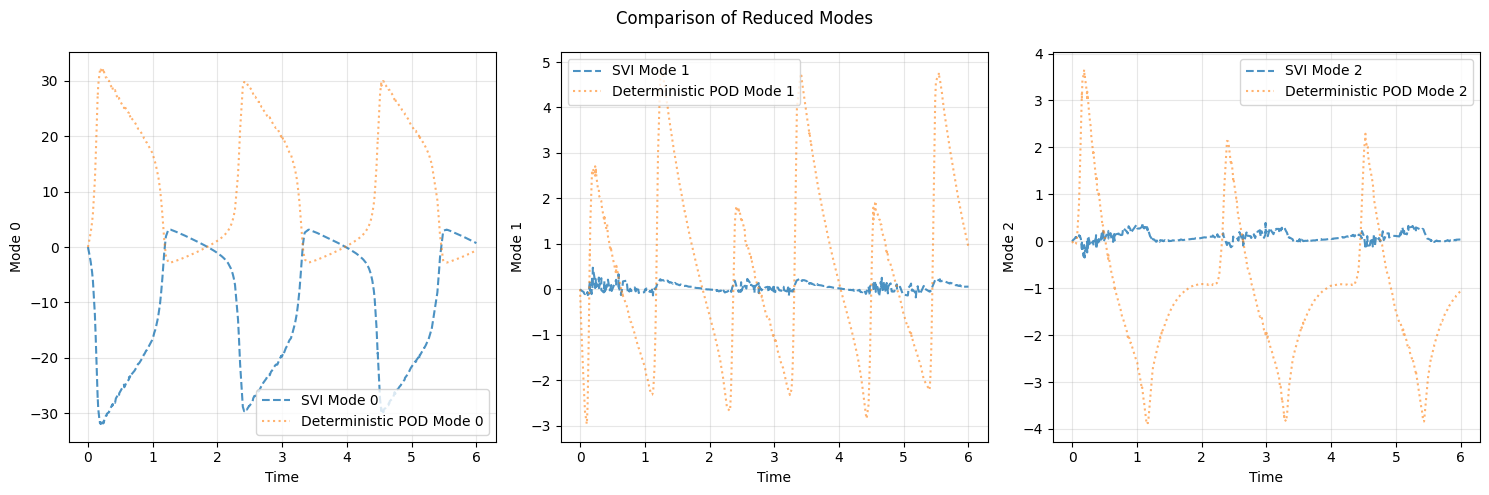

In [8]:
# Verify reconstruction
# reconstructed_mcmc = ppca_mcmc.decompress(compressed_mcmc)
reconstructed_svi = ppca_svi.decompress(compressed_svi)
print(f"\nReconstructed shapes:")
# print(f"MCMC: {reconstructed_mcmc.shape}")  # Should match original (param_dim, time_dim)
print(f"SVI: {reconstructed_svi.shape}")    # Should match original (param_dim, time_dim)

print(f"\nFinal transposed shapes:")
# print(f"MCMC: {compressed_mcmc.shape}")  # Should be (3, time_dim)
print(f"SVI: {compressed_svi.shape}")   # Should be (3, time_dim)

# Plot comparison
plt.figure(figsize=(15, 5))

for i in range(numPODmodes):
    plt.subplot(1, 3, i+1)
    # plt.plot(time_domain_sampled, compressed_mcmc[i], 
    #          label=f'MCMC Mode {i}', alpha=0.8)
    plt.plot(time_domain_sampled, compressed_svi[i], 
             label=f'SVI Mode {i}', linestyle='--', alpha=0.8)
    plt.plot(time_domain_sampled, snapshots_compressed[i], 
             label=f'Deterministic POD Mode {i}', linestyle=':', alpha=0.6)
    plt.xlabel('Time')
    plt.ylabel(f'Mode {i}')
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.suptitle('Comparison of Reduced Modes')
plt.tight_layout()
plt.show()